# Section 2.3 - Mexico and Taiwan are Dominant Sources
Generates: figures/ai-by-country.pdf/png, figures/ai-by-country-category.pdf/png.
**Run after 06** - appends to tables/ai-trade-results.tex.


In [12]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
import os

In [13]:
# Define paths for output files
texfile = "../paper/tables/ai-trade-results.tex"
figfile = "../paper/figures/"

In [14]:
matlist = pd.read_csv('../data-input/hs10_classification_final_v3.csv')

# matlist = pd.read_csv('hs10_datacenter_relevance.csv')

# Convert to category
matlist['relevance'] = matlist['relevance'].astype('category')

# Or specify order if needed (e.g., for sorting/comparisons)
matlist['relevance'] = pd.Categorical(
    matlist['relevance'], 
    categories=['Low', 'Medium', 'High'], 
    ordered=True
)

matlist['primary_category'] = matlist['primary_category'].astype('category')

matlist.rename(columns={'hs10_code': 'HS10'}, inplace=True)

In [15]:
matlist.head()

,relevance,confidence,primary_category,specific_use,reasoning,HS10,description,naics_code,naics_description
0,Low,100,Not_DC_Related,No application in data center context,Live purebred breeding horses are livestock us...,101210010,"HORSES, LIVE, PUREBRED BREEDING MALE",112920,HORSES AND OTHER EQUINE
1,Low,100,Not_DC_Related,Not applicable to data center construction or ...,Live horses are livestock animals with no conn...,101210020,"HORSES, LIVE, PUREBRED BREEDING FEMALE",112920,HORSES AND OTHER EQUINE
2,Low,100,Not_DC_Related,No application in data center construction or ...,Live horses are livestock animals with no rele...,101290090,"HORSES, LIVE, NESOI",112920,HORSES AND OTHER EQUINE
3,Low,100,Not_DC_Related,Not applicable - livestock animals have no rol...,Live donkeys/asses are livestock animals used ...,101300000,"ASSES, LIVE",112920,HORSES AND OTHER EQUINE
4,Low,100,Not_DC_Related,Not applicable to data center operations,Live cattle are agricultural livestock with no...,102210010,"CATTLE, LIVE, PUREBRED BREEDING MALE, DAIRY",11211X,Description not found for NAICS 11211X


In [16]:
df = pd.read_parquet('../data-input/TOTALdata-current.parquet')

df.rename(columns={'I_COMMODITY': 'HS10'}, inplace=True)

df["HS2"] = df["HS10"].str[0:2]
df["HS4"] = df["HS10"].str[0:4]

df["HS10"] = df["HS10"].astype('int64')

df.time = pd.to_datetime(df.time, format="%Y-%m")

df["imports"] = df["CON_VAL_MO"].astype(float)

df["duty"] = df["CAL_DUT_MO"].astype(float)

df.rename({"I_COMMODITY_SDESC": "short_description"}, axis = 1, inplace= True)

# Remove volatile/special HS2 categories
# These categories have prices that are either:
# - Extremely volatile (oil, precious metals)
# - Lumpy/irregular (aircraft)
# - Unreliable/special (pharmaceuticals, special provisions)
excluded_hs2 = ["27", "71", "98", "99"]
df = df[~df["HS2"].isin(excluded_hs2)]

In [17]:
df.tail()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,HS10,short_description,time,COMM_LVL,HS2,HS4,imports,duty
2726615,TOTAL FOR ALL COUNTRIES,1031361,308288,1605514000,"OYSTERS, SMOKED",2026-01-01,HS10,16,1605,1031361.0,308288.0
2726616,TOTAL FOR ALL COUNTRIES,582408,92228,1605515000,"OYSTERS EXCEPT SMOKED, PREPARED OR PRESERVED",2026-01-01,HS10,16,1605,582408.0,92228.0
2726617,TOTAL FOR ALL COUNTRIES,310800,36176,1605520500,SCALLOP PRODUCTS WITH FISH MEAT; PREP MEALS,2026-01-01,HS10,16,1605,310800.0,36176.0
2726618,TOTAL FOR ALL COUNTRIES,412467,91158,1605526000,"SCALLOPS, PREPARED OR PRESERVED",2026-01-01,HS10,16,1605,412467.0,91158.0
2726619,TOTAL FOR ALL COUNTRIES,368316,37195,1605530500,MUSSEL PRODUCTS WITH FISH MEAT; PREP MEALS,2026-01-01,HS10,16,1605,368316.0,37195.0


In [18]:
# Merge Relevance category from matlist onto df
df = df.merge(matlist[['HS10', 'relevance', 'primary_category', "reasoning"	]], on='HS10', how='left')

In [19]:
df.head()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,HS10,short_description,time,COMM_LVL,HS2,HS4,imports,duty,relevance,primary_category,reasoning
0,TOTAL FOR ALL COUNTRIES,773010,0,602400000,"ROSES, GRAFTED OR NOT",2013-01-01,HS10,06,0602,773010.0,0.0,Low,Not_DC_Related,Roses are ornamental plants used for landscapi...
1,TOTAL FOR ALL COUNTRIES,6177543,0,602902000,"ORCHID PLANTS, LIVE",2013-01-01,HS10,06,0602,6177543.0,0.0,Low,Not_DC_Related,Live orchid plants are ornamental/decorative p...
2,TOTAL FOR ALL COUNTRIES,135786,0,602903010,CHRYSANTHEMUMS WITH SOIL ATTACHED TO ROOTS,2013-01-01,HS10,06,0602,135786.0,0.0,Low,Not_DC_Related,These are live flowering plants (chrysanthemum...
3,TOTAL FOR ALL COUNTRIES,169439,0,602903090,"HERBACEOUS PERENNIALS,WTH SOIL ATTACHED,LIVE,N...",2013-01-01,HS10,06,0602,169439.0,0.0,Low,Not_DC_Related,This product is live herbaceous perennial plan...
4,TOTAL FOR ALL COUNTRIES,2177498,25345,602904000,HERBACEOUS PERENNIALS WTHOUT SOIL ATTACHED NESOI,2013-01-01,HS10,06,0602,2177498.0,25345.0,Low,Not_DC_Related,Live herbaceous perennial plants from nurserie...


In [20]:
dfcountry = pd.read_parquet('../data-input/ALL-data-current.parquet')

dfcountry.rename(columns={'I_COMMODITY': 'HS10'}, inplace=True)

dfcountry["HS2"] = dfcountry["HS10"].str[0:2]
dfcountry["HS4"] = dfcountry["HS10"].str[0:4]

dfcountry["HS10"] = dfcountry["HS10"].astype('int64')

dfcountry.time = pd.to_datetime(dfcountry.time, format="%Y-%m")

dfcountry["imports"] = dfcountry["CON_VAL_MO"].astype(float)

dfcountry["duty"] = dfcountry["CAL_DUT_MO"].astype(float)

dfcountry.rename({"I_COMMODITY_SDESC": "short_description"}, axis = 1, inplace= True)

# Remove volatile/special HS2 categories
# These categories have prices that are either:
# - Extremely volatile (oil, precious metals)
# - Lumpy/irregular (aircraft)
# - Unreliable/special (pharmaceuticals, special provisions)
excluded_hs2 = ["27", "71", "98", "99"]
dfcountry = dfcountry[~dfcountry["HS2"].isin(excluded_hs2)]

excluded_cntry = ["TOTAL FOR ALL COUNTRIES", "USMCA (NAFTA)", "EUROPEAN UNION"]
dfcountry = dfcountry[~dfcountry["CTY_NAME"].isin(excluded_cntry)]

# Merge Relevance category from matlist onto df
dfcountry = dfcountry.merge(matlist[['HS10', 'relevance', 'primary_category', "reasoning"	]], on='HS10', how='left')

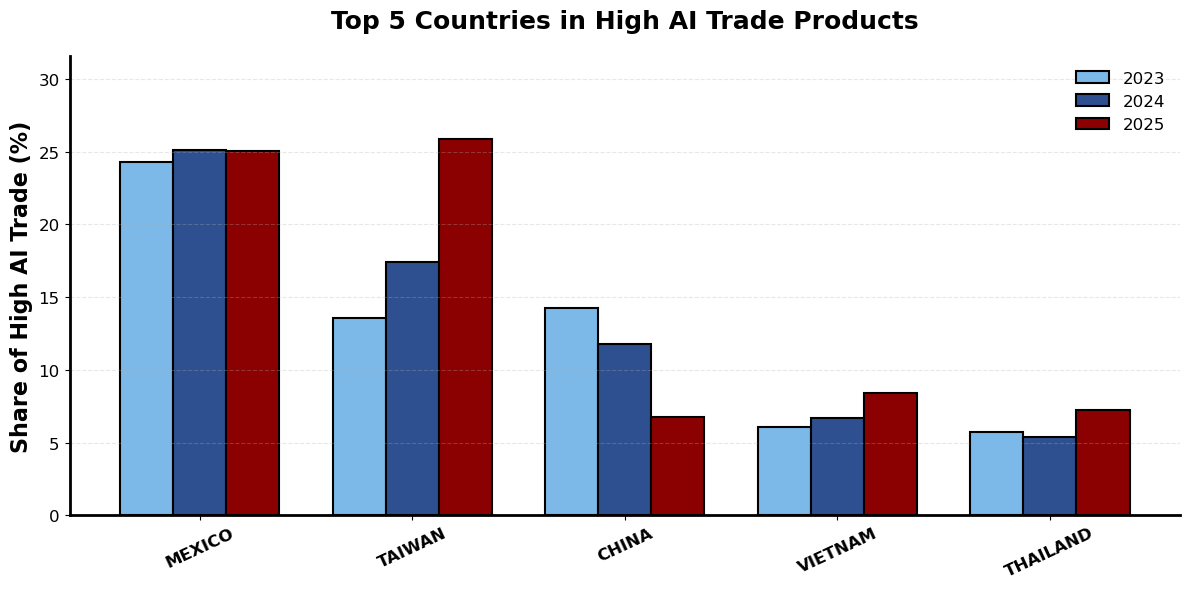


Top 5 countries by share of High AI trade:
  MEXICO: 2023=24.32% | 2024=25.12% | 2025=25.08%
  TAIWAN: 2023=13.57% | 2024=17.43% | 2025=25.90%
  CHINA: 2023=14.22% | 2024=11.78% | 2025=6.77%
  VIETNAM: 2023=6.09% | 2024=6.69% | 2025=8.43%
  THAILAND: 2023=5.70% | 2024=5.41% | 2025=7.27%

Mexico import growth (2025 vs 2024):
  AI-related (High): 40.7%
  Non-AI (Low):      -4.2%
  Total:             6.4%

Canada import growth (2025 vs 2024):
  AI-related (High): -4.2%
  Total:             -8.3%


In [21]:
# Top 5 countries in High AI trade products, split by year (2023, 2024, 2025)

period_years = [2023, 2024, 2025]

country_high = dfcountry[
    (dfcountry['relevance'] == 'High') &
    (dfcountry['time'].dt.year.isin(period_years))
] .copy()

# Select top 5 countries based on combined 2024-2025 imports
country_imports_total = (
    country_high[country_high['time'].dt.year.isin([2024, 2025])]
    .groupby('CTY_NAME', observed=True)['imports']
    .sum()
    .sort_values(ascending=False)
)
top5_countries = country_imports_total.head(5).index.tolist()

# Compute yearly shares: country high-AI imports / total high-AI imports in that year
yearly_country_imports = (
    country_high[country_high['CTY_NAME'].isin(top5_countries)]
    .groupby(['CTY_NAME', country_high['time'].dt.year], observed=True)['imports']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=period_years, fill_value=0)
)

yearly_high_totals = (
    country_high.groupby(country_high['time'].dt.year, observed=True)['imports']
    .sum()
)

plot_df = pd.DataFrame({
    '2023': (yearly_country_imports[2023] / yearly_high_totals.loc[2023]) * 100,
    '2024': (yearly_country_imports[2024] / yearly_high_totals.loc[2024]) * 100,
    '2025': (yearly_country_imports[2025] / yearly_high_totals.loc[2025]) * 100
}).loc[top5_countries]

# Plot grouped bars
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(plot_df.index))
width = 0.25

bars_2023 = ax.bar(
    x - width,
    plot_df['2023'].values,
    width,
    label='2023',
    color='#7CB9E8',
    edgecolor='black',
    linewidth=1.5
)

bars_2024 = ax.bar(
    x,
    plot_df['2024'].values,
    width,
    label='2024',
    color='#2E5090',
    edgecolor='black',
    linewidth=1.5
)

bars_2025 = ax.bar(
    x + width,
    plot_df['2025'].values,
    width,
    label='2025',
    color='#8B0000',
    edgecolor='black',
    linewidth=1.5
)

# Formatting (consistent with existing style)
ax.set_ylabel('Share of High AI Trade (%)', fontsize=16, fontweight='bold')
ax.set_title('Top 5 Countries in High AI Trade Products', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, max(plot_df['2023'].max(), plot_df['2024'].max(), plot_df['2025'].max()) * 1.22)

ax.tick_params(axis='x', labelsize=12, rotation=25)
ax.tick_params(axis='y', labelsize=12)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.legend(fontsize=12, frameon=False, loc='upper right')

plt.savefig(figfile+"ai-by-country.png", bbox_inches = "tight")
plt.savefig(figfile+"ai-by-country.pdf", bbox_inches = "tight")

plt.tight_layout()
plt.show()

# Compute import growth in 2025 relative to 2024 for Canada and Mexico (High AI products)
country_year_imports_high = (
    country_high.groupby(['CTY_NAME', country_high['time'].dt.year], observed=True)['imports']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=period_years, fill_value=0)
)

canada_2024_high = country_year_imports_high.loc['CANADA', 2024] if 'CANADA' in country_year_imports_high.index else 0.0
canada_2025_high = country_year_imports_high.loc['CANADA', 2025] if 'CANADA' in country_year_imports_high.index else 0.0
mexico_2024_high = country_year_imports_high.loc['MEXICO', 2024] if 'MEXICO' in country_year_imports_high.index else 0.0
mexico_2025_high = country_year_imports_high.loc['MEXICO', 2025] if 'MEXICO' in country_year_imports_high.index else 0.0

canada_growth_2025_vs_2024_high = ((canada_2025_high - canada_2024_high) / canada_2024_high) * 100 if canada_2024_high > 0 else 0.0
mexico_growth_2025_vs_2024_high = ((mexico_2025_high - mexico_2024_high) / mexico_2024_high) * 100 if mexico_2024_high > 0 else 0.0

# Compute total import growth in 2025 relative to 2024 for Canada and Mexico (all relevance)
country_total = dfcountry[dfcountry['time'].dt.year.isin([2024, 2025])].copy()
country_year_imports_total = (
    country_total.groupby(['CTY_NAME', country_total['time'].dt.year], observed=True)['imports']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=[2024, 2025], fill_value=0)
)

canada_2024_total = country_year_imports_total.loc['CANADA', 2024] if 'CANADA' in country_year_imports_total.index else 0.0
canada_2025_total = country_year_imports_total.loc['CANADA', 2025] if 'CANADA' in country_year_imports_total.index else 0.0
mexico_2024_total = country_year_imports_total.loc['MEXICO', 2024] if 'MEXICO' in country_year_imports_total.index else 0.0
mexico_2025_total = country_year_imports_total.loc['MEXICO', 2025] if 'MEXICO' in country_year_imports_total.index else 0.0

canada_growth_2025_vs_2024_total = ((canada_2025_total - canada_2024_total) / canada_2024_total) * 100 if canada_2024_total > 0 else 0.0
mexico_growth_2025_vs_2024_total = ((mexico_2025_total - mexico_2024_total) / mexico_2024_total) * 100 if mexico_2024_total > 0 else 0.0

# Compute non-AI (Low relevance) import growth for Mexico
country_low = dfcountry[
    (dfcountry['relevance'] == 'Low') &
    (dfcountry['time'].dt.year.isin([2024, 2025]))
].copy()
country_year_imports_low = (
    country_low.groupby(['CTY_NAME', country_low['time'].dt.year], observed=True)['imports']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=[2024, 2025], fill_value=0)
)

mexico_2024_low = country_year_imports_low.loc['MEXICO', 2024] if 'MEXICO' in country_year_imports_low.index else 0.0
mexico_2025_low = country_year_imports_low.loc['MEXICO', 2025] if 'MEXICO' in country_year_imports_low.index else 0.0
mexico_growth_2025_vs_2024_low = ((mexico_2025_low - mexico_2024_low) / mexico_2024_low) * 100 if mexico_2024_low > 0 else 0.0

with open(texfile, 'a') as f:
    f.write(f'\\def\\canadaHighAiImportGrowthTwentyFiveVsTwentyFour{{{canada_growth_2025_vs_2024_high:.1f}}} % Canada high-AI import growth in 2025 vs 2024 (%)\n')
    f.write(f'\\def\\mexicoHighAiImportGrowthTwentyFiveVsTwentyFour{{{mexico_growth_2025_vs_2024_high:.1f}}} % Mexico high-AI import growth in 2025 vs 2024 (%)\n')
    f.write(f'\\def\\canadaTotalImportGrowthTwentyFiveVsTwentyFour{{{canada_growth_2025_vs_2024_total:.1f}}} % Canada total import growth in 2025 vs 2024 (%)\n')
    f.write(f'\\def\\mexicoTotalImportGrowthTwentyFiveVsTwentyFour{{{mexico_growth_2025_vs_2024_total:.1f}}} % Mexico total import growth in 2025 vs 2024 (%)\n')
    f.write(f'\\def\\mexicoLowAiImportGrowthTwentyFiveVsTwentyFour{{{mexico_growth_2025_vs_2024_low:.1f}}} % Mexico non-AI import growth in 2025 vs 2024 (%)\n')

print('\nTop 5 countries by share of High AI trade:')
for country in plot_df.index:
    print(
        f"  {country}: 2023={plot_df.loc[country, '2023']:.2f}% | "
        f"2024={plot_df.loc[country, '2024']:.2f}% | "
        f"2025={plot_df.loc[country, '2025']:.2f}%"
    )

print('\nMexico import growth (2025 vs 2024):')
print(f"  AI-related (High): {mexico_growth_2025_vs_2024_high:.1f}%")
print(f"  Non-AI (Low):      {mexico_growth_2025_vs_2024_low:.1f}%")
print(f"  Total:             {mexico_growth_2025_vs_2024_total:.1f}%")

print('\nCanada import growth (2025 vs 2024):')
print(f"  AI-related (High): {canada_growth_2025_vs_2024_high:.1f}%")
print(f"  Total:             {canada_growth_2025_vs_2024_total:.1f}%")

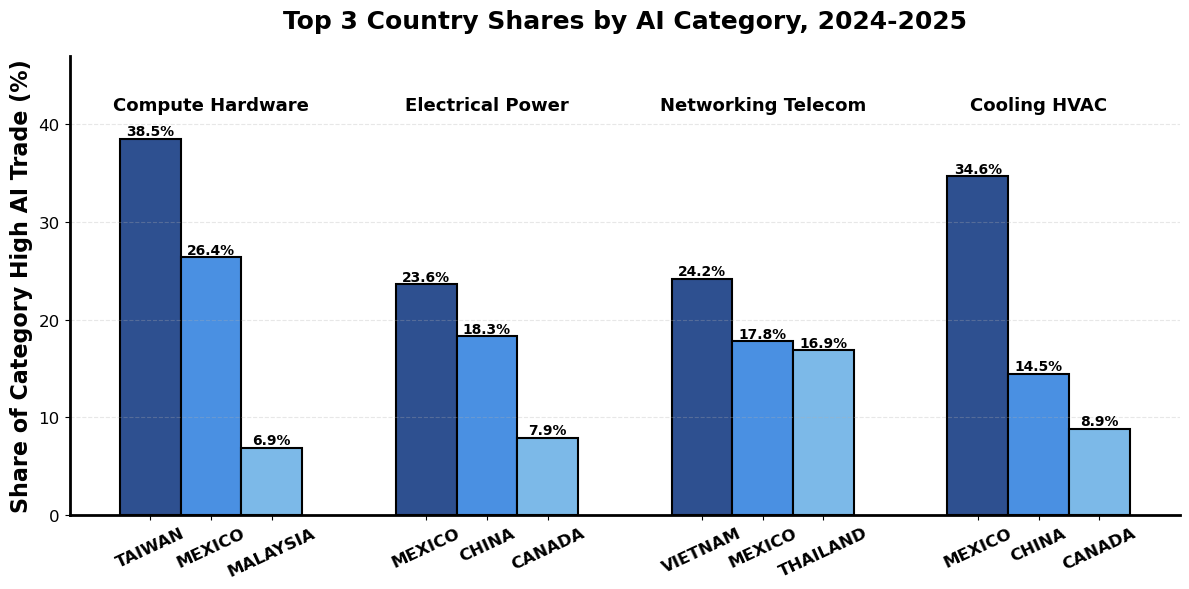


Top 3 country shares within each category (2024-2025):
  Compute Hardware:
    1) TAIWAN: 38.5%
    2) MEXICO: 26.4%
    3) MALAYSIA: 6.9%
  Electrical Power:
    1) MEXICO: 23.6%
    2) CHINA: 18.3%
    3) CANADA: 7.9%
  Networking Telecom:
    1) VIETNAM: 24.2%
    2) MEXICO: 17.8%
    3) THAILAND: 16.9%
  Cooling HVAC:
    1) MEXICO: 34.6%
    2) CHINA: 14.5%
    3) CANADA: 8.9%


In [22]:
# Top 3 country shares within each top AI category (2024-2025)

period_years = [2024, 2025]
category_list = ['Compute_Hardware', 'Electrical_Power', 'Networking_Telecom', 'Cooling_HVAC']

cat_country_high = dfcountry[
    (dfcountry['relevance'] == 'High') &
    (dfcountry['primary_category'].isin(category_list)) &
    (dfcountry['time'].dt.year.isin(period_years))
] .copy()

# Compute top-3 country shares within each category
share_by_rank = {'Top 1': [], 'Top 2': [], 'Top 3': []}
country_names_by_cat = {}

for category in category_list:
    category_data = cat_country_high[cat_country_high['primary_category'] == category]
    country_imports = category_data.groupby('CTY_NAME', observed=True)['imports'].sum().sort_values(ascending=False)

    category_total = country_imports.sum()
    top3 = country_imports.head(3)

    # Pad if fewer than 3 countries
    top3_shares = (top3 / category_total * 100).tolist()
    top3_names = top3.index.tolist()

    while len(top3_shares) < 3:
        top3_shares.append(0.0)
        top3_names.append('N/A')

    share_by_rank['Top 1'].append(top3_shares[0])
    share_by_rank['Top 2'].append(top3_shares[1])
    share_by_rank['Top 3'].append(top3_shares[2])

    country_names_by_cat[category] = top3_names

# Plot grouped bars
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(category_list))
width = 0.22

bars_top1 = ax.bar(
    x - width,
    share_by_rank['Top 1'],
    width,
    label='Top 1 Country',
    color='#2E5090',
    edgecolor='black',
    linewidth=1.5
)

bars_top2 = ax.bar(
    x,
    share_by_rank['Top 2'],
    width,
    label='Top 2 Country',
    color='#4A90E2',
    edgecolor='black',
    linewidth=1.5
)

bars_top3 = ax.bar(
    x + width,
    share_by_rank['Top 3'],
    width,
    label='Top 3 Country',
    color='#7CB9E8',
    edgecolor='black',
    linewidth=1.5
)

# Labels on bars (percent values)
for bars in [bars_top1, bars_top2, bars_top3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.05,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# X-axis labels: country names under each bar
bar_positions = []
bar_labels = []
for idx, category in enumerate(category_list):
    c1, c2, c3 = country_names_by_cat[category]
    bar_positions.extend([x[idx] - width, x[idx], x[idx] + width])
    bar_labels.extend([c1, c2, c3])

ax.set_xticks(bar_positions)
ax.set_xticklabels(bar_labels)

# Category annotations centered on middle bar of each group (~42%)
max_share = max(max(share_by_rank['Top 1']), max(share_by_rank['Top 2']), max(share_by_rank['Top 3']))
category_label_y = 42
top_ylim = max(max_share * 1.22, category_label_y + 3)

for idx, category in enumerate(category_list):
    ax.text(
        x[idx],
        category_label_y,
        category.replace('_', ' '),
        ha='center',
        va='center',
        fontsize=13,
        fontweight='bold'
    )

# Formatting (consistent style)
ax.set_ylabel('Share of Category High AI Trade (%)', fontsize=16, fontweight='bold')
ax.set_title('Top 3 Country Shares by AI Category, 2024-2025', fontsize=18, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, top_ylim)

ax.tick_params(axis='x', labelsize=12, rotation=25)
ax.tick_params(axis='y', labelsize=12)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

plt.savefig(figfile+"ai-by-country-category.png", bbox_inches = "tight")
plt.savefig(figfile+"ai-by-country-category.pdf", bbox_inches = "tight")

plt.tight_layout()
plt.show()

print('\nTop 3 country shares within each category (2024-2025):')
for category in category_list:
    c1, c2, c3 = country_names_by_cat[category]
    i = category_list.index(category)
    print(f"  {category.replace('_', ' ')}:")
    print(f"    1) {c1}: {share_by_rank['Top 1'][i]:.1f}%")
    print(f"    2) {c2}: {share_by_rank['Top 2'][i]:.1f}%")
    print(f"    3) {c3}: {share_by_rank['Top 3'][i]:.1f}%")